In [1]:
import pandas as pd              # Para análisis de datos
import numpy as np               # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para gráficos
import seaborn as sns            # Para gráficos bonitos

Método de Lagrange para obtener un polinomio interpolador (pagina 399 Chapra). Para un polinomio $f(x)$ de grado $n$ necesitamos conocer $n+1$ puntos $(x_{i},f(x_{i}))$. El polinomio se construye como:

$P(x) = \sum_{k=0}^{n} f(x_i) L_{n,k}(x)$ con $L_{n,k}(x) = \prod_{i=0,i\neq k}^{n} \frac{(x-x_i)}{(x_k-x_i)}$ . 

Necesitamos saber los puntos $\vec{x_i}$ y $\vec{y_i}(x)$, el número $k$ hasta el que queremos llegar en $L_{n,k}$, y el punto donde queremos interpolar $x$.

In [4]:
#L_{nk}

def L_nk(n,k,x,xi): 
    # n = grado del polinomio
    # k = indice que nos indica de que punto es L_nk (hay n+1 L_nk's)
    # x = variable x
    # xi = vector de n+1 puntos 

    Lnk = 1

    for j in range (0,n+1,1): #n+1 ya que este termino no se cuenta en el for (el for llega hasta n)
        if j==k:
            continue
        else:
            Lnk = Lnk * (x-xi[j])/(xi[k]-xi[j])

    return Lnk

In [5]:
# Polinomio interpolador de Lagrange

def PolyLagrange(x,xi,yi):
    # x = variable x
    # xi = vector de n+1 puntos 
    # yi = vector de f(xi) con las n+1 imagenes de xi

    n = len(xi) - 1

    Px = 0

    for k in range(0,n+1,1): #n+1 ya que este termino no se cuenta en el for (el for llega hasta n)
        Px = Px + yi[k]*L_nk(n,k,x,xi)

    return Px

Los puntos que tenemos son $\vec{x}=(0,20,40)$ y $\vec{y}(x)=(3.85,0.8,0.212)$, y queremos interpolar es y(x=15).

In [9]:
xi=[0,20,40]
yi=[3.85,0.8,0.212]
x = 15

interpol = PolyLagrange(x,xi,yi)

print("El resultado de interpolar en x=", x, " es y(x)=", interpol, ".")

El resultado de interpolar en x= 15  es y(x)= 1.3316875 .


La comprobación gráfica es:

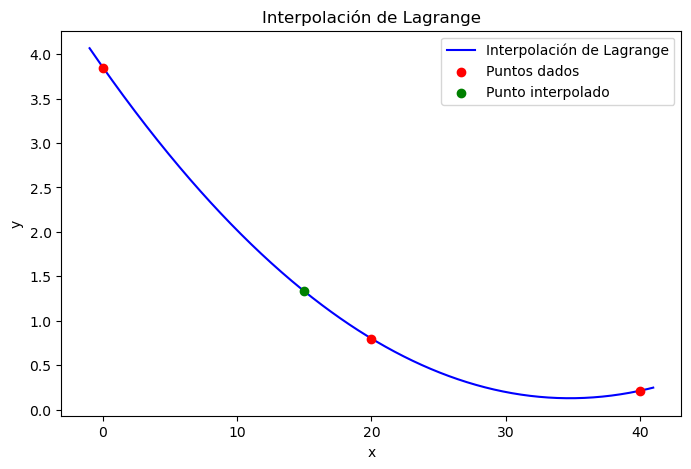

In [10]:
x_vals = np.linspace(min(xi) - 1, max(xi) + 1, 500)
y_vals = [PolyLagrange(x, xi, yi) for x in x_vals]

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='Interpolación de Lagrange', color='blue')
plt.scatter(xi, yi, color='red', label='Puntos dados', zorder=5)
plt.scatter(x, PolyLagrange(x,xi,yi), color='green', label='Punto interpolado', zorder=5)
plt.title('Interpolación de Lagrange')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(False)
plt.show()